In [33]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [35]:
df_2015 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2015.csv')
df_2017 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2017.csv')
df_2019 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2019.csv')
df_2021 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2021.csv')
df_2023 = pd.read_csv('./기부예측_자료모음/원본_복지_사회참여_문화와여가_소득과소비_노동_데이터/df_2023.csv')

In [36]:
df_2015['조사년도'] = 2015
df_2017['조사년도'] = 2017
df_2019['조사년도'] = 2019
df_2021['조사년도'] = 2021
df_2023['조사년도'] = 2023

In [37]:
df = pd.concat(
    [df_2015, df_2017, df_2019, df_2021, df_2023],
    ignore_index=True
)
df['조사년도'].isnull().sum()

np.int64(0)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184915 entries, 0 to 184914
Columns: 465 entries, 가구일련번호 to 분류코드_다문화가족여부
dtypes: float64(382), int64(49), object(34)
memory usage: 656.0+ MB


In [39]:
target_col = '기부여부'

In [40]:
# 기부:1, 미기부:0
df['기부여부'] = df['기부여부'].replace({2:0})

In [41]:
# unique 값이 1개인 컬럼 찾기
one_unique_cols = [col for col in df.columns if df[col].nunique() == 1]
print("unique가 1개인 컬럼:", one_unique_cols)
df = df.drop(columns=one_unique_cols)

unique가 1개인 컬럼: ['분류코드_만13세이상여부', '분류코드_만15세이상여부', '분류코드_점유형태2', '분류코드_주택형태2', '분류코드_연령2', '분류코드_가구원수2', '분류코드_연령15', '분류코드_연령16']


In [43]:
drop_cols_text = '''
기부내용_기타_물품횟수
기부내용_기타_현금금액
기부내용_기타_현금주기
기부내용_기타_현금횟수
기부내용_대상자직접후원_물품횟수
기부내용_대상자직접후원_현금금액
기부내용_대상자직접후원_현금주기
기부내용_대상자직접후원_현금횟수
기부내용_모금단체후원_현금금액
기부내용_모금단체후원_현금주기
기부내용_모금단체후원_현금횟수
기부내용_물품주기
기부내용_물품횟수
기부내용_물품후원단체후원_물품횟수
기부내용_언론기관후원_물품횟수
기부내용_언론기관후원_현금금액
기부내용_언론기관후원_현금주기
기부내용_언론기관후원_현금횟수
기부내용_종교단체후원_물품횟수
기부내용_종교단체후원_현금금액
기부내용_종교단체후원_현금주기
기부내용_종교단체후원_현금횟수
기부내용_직장기업후원_물품횟수
기부내용_직장기업후원_현금금액
기부내용_직장기업후원_현금주기
기부내용_직장기업후원_현금횟수
기부대상인지경로
기부사유
분류코드_기부여부
분류코드_물품기부여부
분류코드_물품기부정기성여부
분류코드_현금기부여부
분류코드_현금기부정기성여부
정기기부_물품기부_주기
정기기부_물품기부주기
정기기부_물품기부여부
정기기부_현금기부_주기
정기기부_현금기부여부
정기기부_현금기부주기
분류코드_연령성별1
분류코드_연령성별10
분류코드_연령성별11
분류코드_연령성별2
분류코드_연령성별3
분류코드_연령성별4
분류코드_연령성별5
분류코드_연령성별6
분류코드_연령성별7
분류코드_연령성별8
분류코드_연령성별9
가구일련번호
가구가중값
가구원가중값
가구번호
표본층번호
승수(가구)_weight
승수(가구원)_weight
분류코드_직업대분류
분류코드_직업별
분류코드_직장산업대분류
'''
drop_cols_original = drop_cols_text.split()
df = df.drop(columns=[col for col in drop_cols_original if col in df.columns])

In [44]:
drop_cols_text = '''
기부종류
기부내용_기타_물품횟수
기부내용_기타_현금금액
기부내용_기타_현금주기
기부내용_기타_현금횟수
기부내용_대상자직접후원_물품횟수
기부내용_대상자직접후원_현금금액
기부내용_대상자직접후원_현금주기
기부내용_대상자직접후원_현금횟수
기부내용_모금단체후원_현금금액
기부내용_모금단체후원_현금주기
기부내용_모금단체후원_현금횟수
기부내용_물품주기
기부내용_물품횟수
기부내용_물품후원단체후원_물품횟수
기부내용_언론기관후원_물품횟수
기부내용_언론기관후원_현금금액
기부내용_언론기관후원_현금주기
기부내용_언론기관후원_현금횟수
기부내용_종교단체후원_물품횟수
기부내용_종교단체후원_현금금액
기부내용_종교단체후원_현금주기
기부내용_종교단체후원_현금횟수
기부내용_직장기업후원_물품횟수
기부내용_직장기업후원_현금금액
기부내용_직장기업후원_현금주기
기부내용_직장기업후원_현금횟수
기부대상인지경로
기부사유
미기부사유
분류코드_기부여부
분류코드_물품기부여부
분류코드_물품기부정기성여부
분류코드_현금기부여부
분류코드_현금기부정기성여부
정기기부_물품기부_주기
정기기부_물품기부주기
정기기부_물품기부여부
정기기부_현금기부_주기
정기기부_현금기부여부
정기기부_현금기부주기
분류코드_연령성별1
분류코드_연령성별10
분류코드_연령성별11
분류코드_연령성별2
분류코드_연령성별3
분류코드_연령성별4
분류코드_연령성별5
분류코드_연령성별6
분류코드_연령성별7
분류코드_연령성별8
분류코드_연령성별9
가구일련번호
가구가중값
가구원가중값
가구번호
승수(가구)_weight
승수(가구원)_weight
분류코드_직업대분류
분류코드_직업별
분류코드_직장산업대분류
'''
drop_cols_original = drop_cols_text.split()
df = df.drop(columns=[col for col in drop_cols_original if col in df.columns])

In [45]:
value_continued = '''
만연령
사회적관계망_가사도움요청대상인원수
사회적관계망_자금차입도움요청대상인원수
사회적관계망_대화상대도움요청대상인원수
자원봉사_아동청소년노인장애인재소자관련횟수
자원봉사_아동청소년노인장애인재소자관련시간수
자원봉사활동_환경보전범죄예방관련횟수
자원봉사활동_환경보전범죄예방관련시간수
자원봉사활동_자녀교육관련횟수
자원봉사활동_자녀교육관련시간수
자원봉사활동_국가지역행사관련횟수
자원봉사활동_국가지역행사관련시간수
자원봉사활동_재해지역주민돕기시설복구관련횟수
자원봉사활동_재해지역주민돕기시설복구관련시간수
자원봉사활동_기타일반봉사관련횟수
자원봉사활동_기타일반봉사관련시간수
독서_잡지류권수
독서_교양서적권수
독서_직업직무관련서적권수
독서_생활취미정보서적권수
독서_기타권수
문화예술스포츠관람_음악연주회횟수
문화예술스포츠관람_연극마당극뮤지컬횟수
문화예술스포츠관람_무용횟수
문화예술스포츠관람_영화횟수
문화예술스포츠관람_박물관횟수
문화예술스포츠관람_미술관횟수
문화예술스포츠관람_스포츠횟수
레저시설_관광명소유적지국립공원이용횟수
레저시설_온천장스파이용횟수
레저시설_골프장이용횟수
레저시설_스키장이용횟수
레저시설_해수욕장이용횟수
레저시설_산림욕장휴양림이용횟수
레저시설_놀이공원이용횟수
레저시설_수영장워터파크포함이용횟수
레저시설_기타이용횟수
국내관광여행_숙박여행횟수
국내관광여행_숙박여행1회평균숙박일수
국내관광여행_당일여행횟수
해외여행경험_관광횟수
해외여행경험_가족친지관련횟수
해외여행경험_업무횟수
해외여행경험_교육횟수
'''

numeric_cols_original = value_continued.split()
# df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [46]:
value_nominal = '''
미기부사유
유산기부의사여부
가구주와의관계
거처의종류
기부문화확산_1순위
기부문화확산_2순위
기부문화확산_3순위
기부문화확산1순위
기부문화확산2순위
기부문화확산3순위
기부여부
기부희망분야1순위
기부희망분야2순위
기부희망분야3순위
기부종류
기부하지않은이유
기부한이유
유산기부의사여부
기부희망분야_1순위
기부희망분야_2순위
기부희망분야_3순위
긴축소비지출항목_1순위
긴축소비지출항목_2순위
긴축소비지출항목_3순위
노후준비방법_노후미준비사유
노후준비방법_부수적인것
노후준비방법_부수적방법
노후를보내고싶은방법
노후를위한사회적관심사
노후를위한사회적역할
노후생활주요활동_1순위
노후생활주요활동_2순위
노후생활주요활동_3순위
노후준비방법_주된방법
노후희망활동_1순위
노후희망활동_2순위
노후희망활동_3순위
노후희망활동
분류코드맞벌이여부
분류코드맞벌이여부2
분류코드산업별
분류코드_맞벌이1여부
분류코드_맞벌이2여부
분류코드_산업별
분류코드_점유형태
분류코드_점유형태1
분류코드_점유형태2
분류코드_종사자지위
분류코드_주택형태
분류코드_주택형태1
분류코드_주택형태2
분류코드_청소년교육정도코드1
분류코드_청소년교육정도코드2
분류코드_혼인상태
분류코드_혼인상태2
산업
생활비마련방법
생활비마련방법_본인및배우자부담
선호장례방법
신문인터넷신문_보는분야
신문일반신문_보는분야
앞으로하고싶은여가활동1순위
앞으로하고싶은여가활동2순위
앞으로하고싶은여가활동3순위
여가활용_불만족사유
여가활동_동반자
여성취업장애요인_1순위
여성취업장애요인_2순위
여성취업장애요인_3순위
여성취업에대한견해
우선실시장애인복지사업_1순위
우선실시장애인복지사업_2순위
우선실시장애인복지사업_3순위
원격수업이효과적이지않은이유1순위
원격수업이효과적이지않은이유2순위
원격수업이효과적이지않은이유3순위
자원봉사활동인지경로
장애인과의유대관계여부및대상
장애인과의유대관계여부및대상대상1순위
장애인과의유대관계여부및대상대상2순위
장애인과의유대관계여부및대상대상3순위
장애인유대관계대상_1순위
장애인유대관계대상_2순위
장애인유대관계대상_3순위
재택근무가비효율적인이유1순위
재택근무가비효율적인이유2순위
재택근무가비효율적인이유3순위
재학상태
전문성을활용한자원봉사활동
전문성활용자원봉사활동내용
점유형태
종사상의지위
주말여가활동_동반자
주말휴일여가활용_1순위
주말휴일여가활용_2순위
주말휴일여가활용_3순위
주중여가활동_동반자
주중여가활용_1순위
주중여가활용_2순위
주중여가활용_3순위
직업선택요인_1순위
직업선택요인_2순위
직업선택요인_3순위
직업대분류
직업
직장산업대분류
참여단체_1순위
참여단체_2순위
참여단체_3순위
청년이선호하는직장
향후추가대상공공시설_3순위
행정구역(시도)
향후추가대상공공시설_1순위
향후추가대상공공시설_2순위
향후추가대상복지서비스_1순위
향후추가대상복지서비스_2순위
향후추가대상복지서비스_3순위
향후희망거처
향후희망여가활동_1순위
향후희망여가활동_2순위
향후희망여가활동_3순위
현재자녀동거사유_1순위
현재자녀동거사유_2순위
현재자녀동거사유_3순위
현재자녀비동거사유_1순위
현재자녀비동거사유_2순위
현재자녀비동거사유_3순위
혼인상태
'''

nominal_cols_original = value_nominal.split()

In [47]:
ordinal_cols_original = [col for col in df.columns
                if col not in numeric_cols_original and col not in nominal_cols_original and col != target_col]
print(len(ordinal_cols_original))

287


In [48]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

   조사년도      기부여부
0  2015  0.292220
1  2017  0.255289
2  2019  0.250950
3  2021  0.211570
4  2023  0.230398


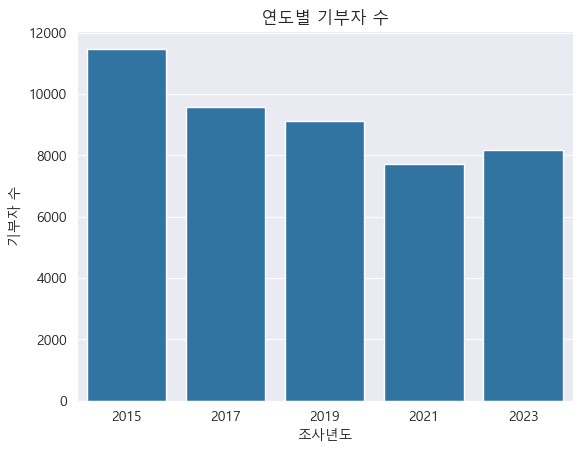

In [49]:
donation_counts = df[df['기부여부'] == 1]['조사년도'].value_counts()
rate = df.groupby('조사년도')['기부여부'].mean().reset_index()
print(rate)
sns.barplot(x=donation_counts.index, y=donation_counts.values)
plt.title("연도별 기부자 수")
plt.ylabel("기부자 수")
plt.xlabel("조사년도")
plt.show()

차이:  1532


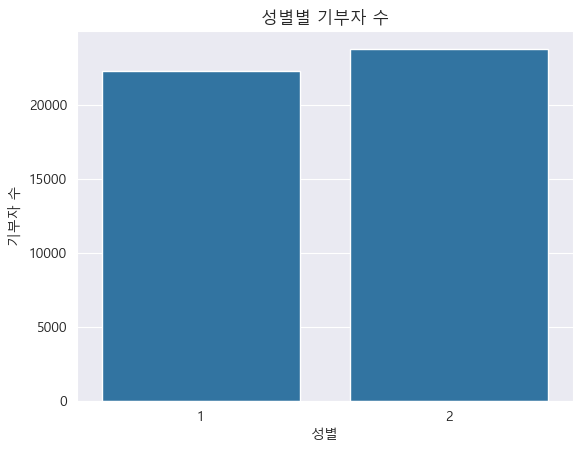

In [20]:
donation_counts = df[df['기부여부'] == 1]['성별'].value_counts()
print("차이: ", donation_counts[2]-donation_counts[1])
sns.barplot(x=donation_counts.index, y=donation_counts.values)
plt.title("성별별 기부자 수")
plt.ylabel("기부자 수")
plt.xlabel("성별")
plt.show()

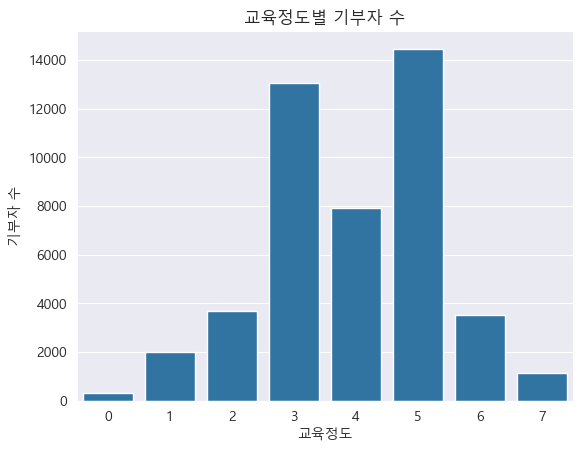

In [21]:
donation_counts = df[df['기부여부'] == 1]['교육정도'].value_counts()
sns.barplot(x=donation_counts.index, y=donation_counts.values)
plt.title("교육정도별 기부자 수")
plt.ylabel("기부자 수")
plt.xlabel("교육정도")
plt.show()

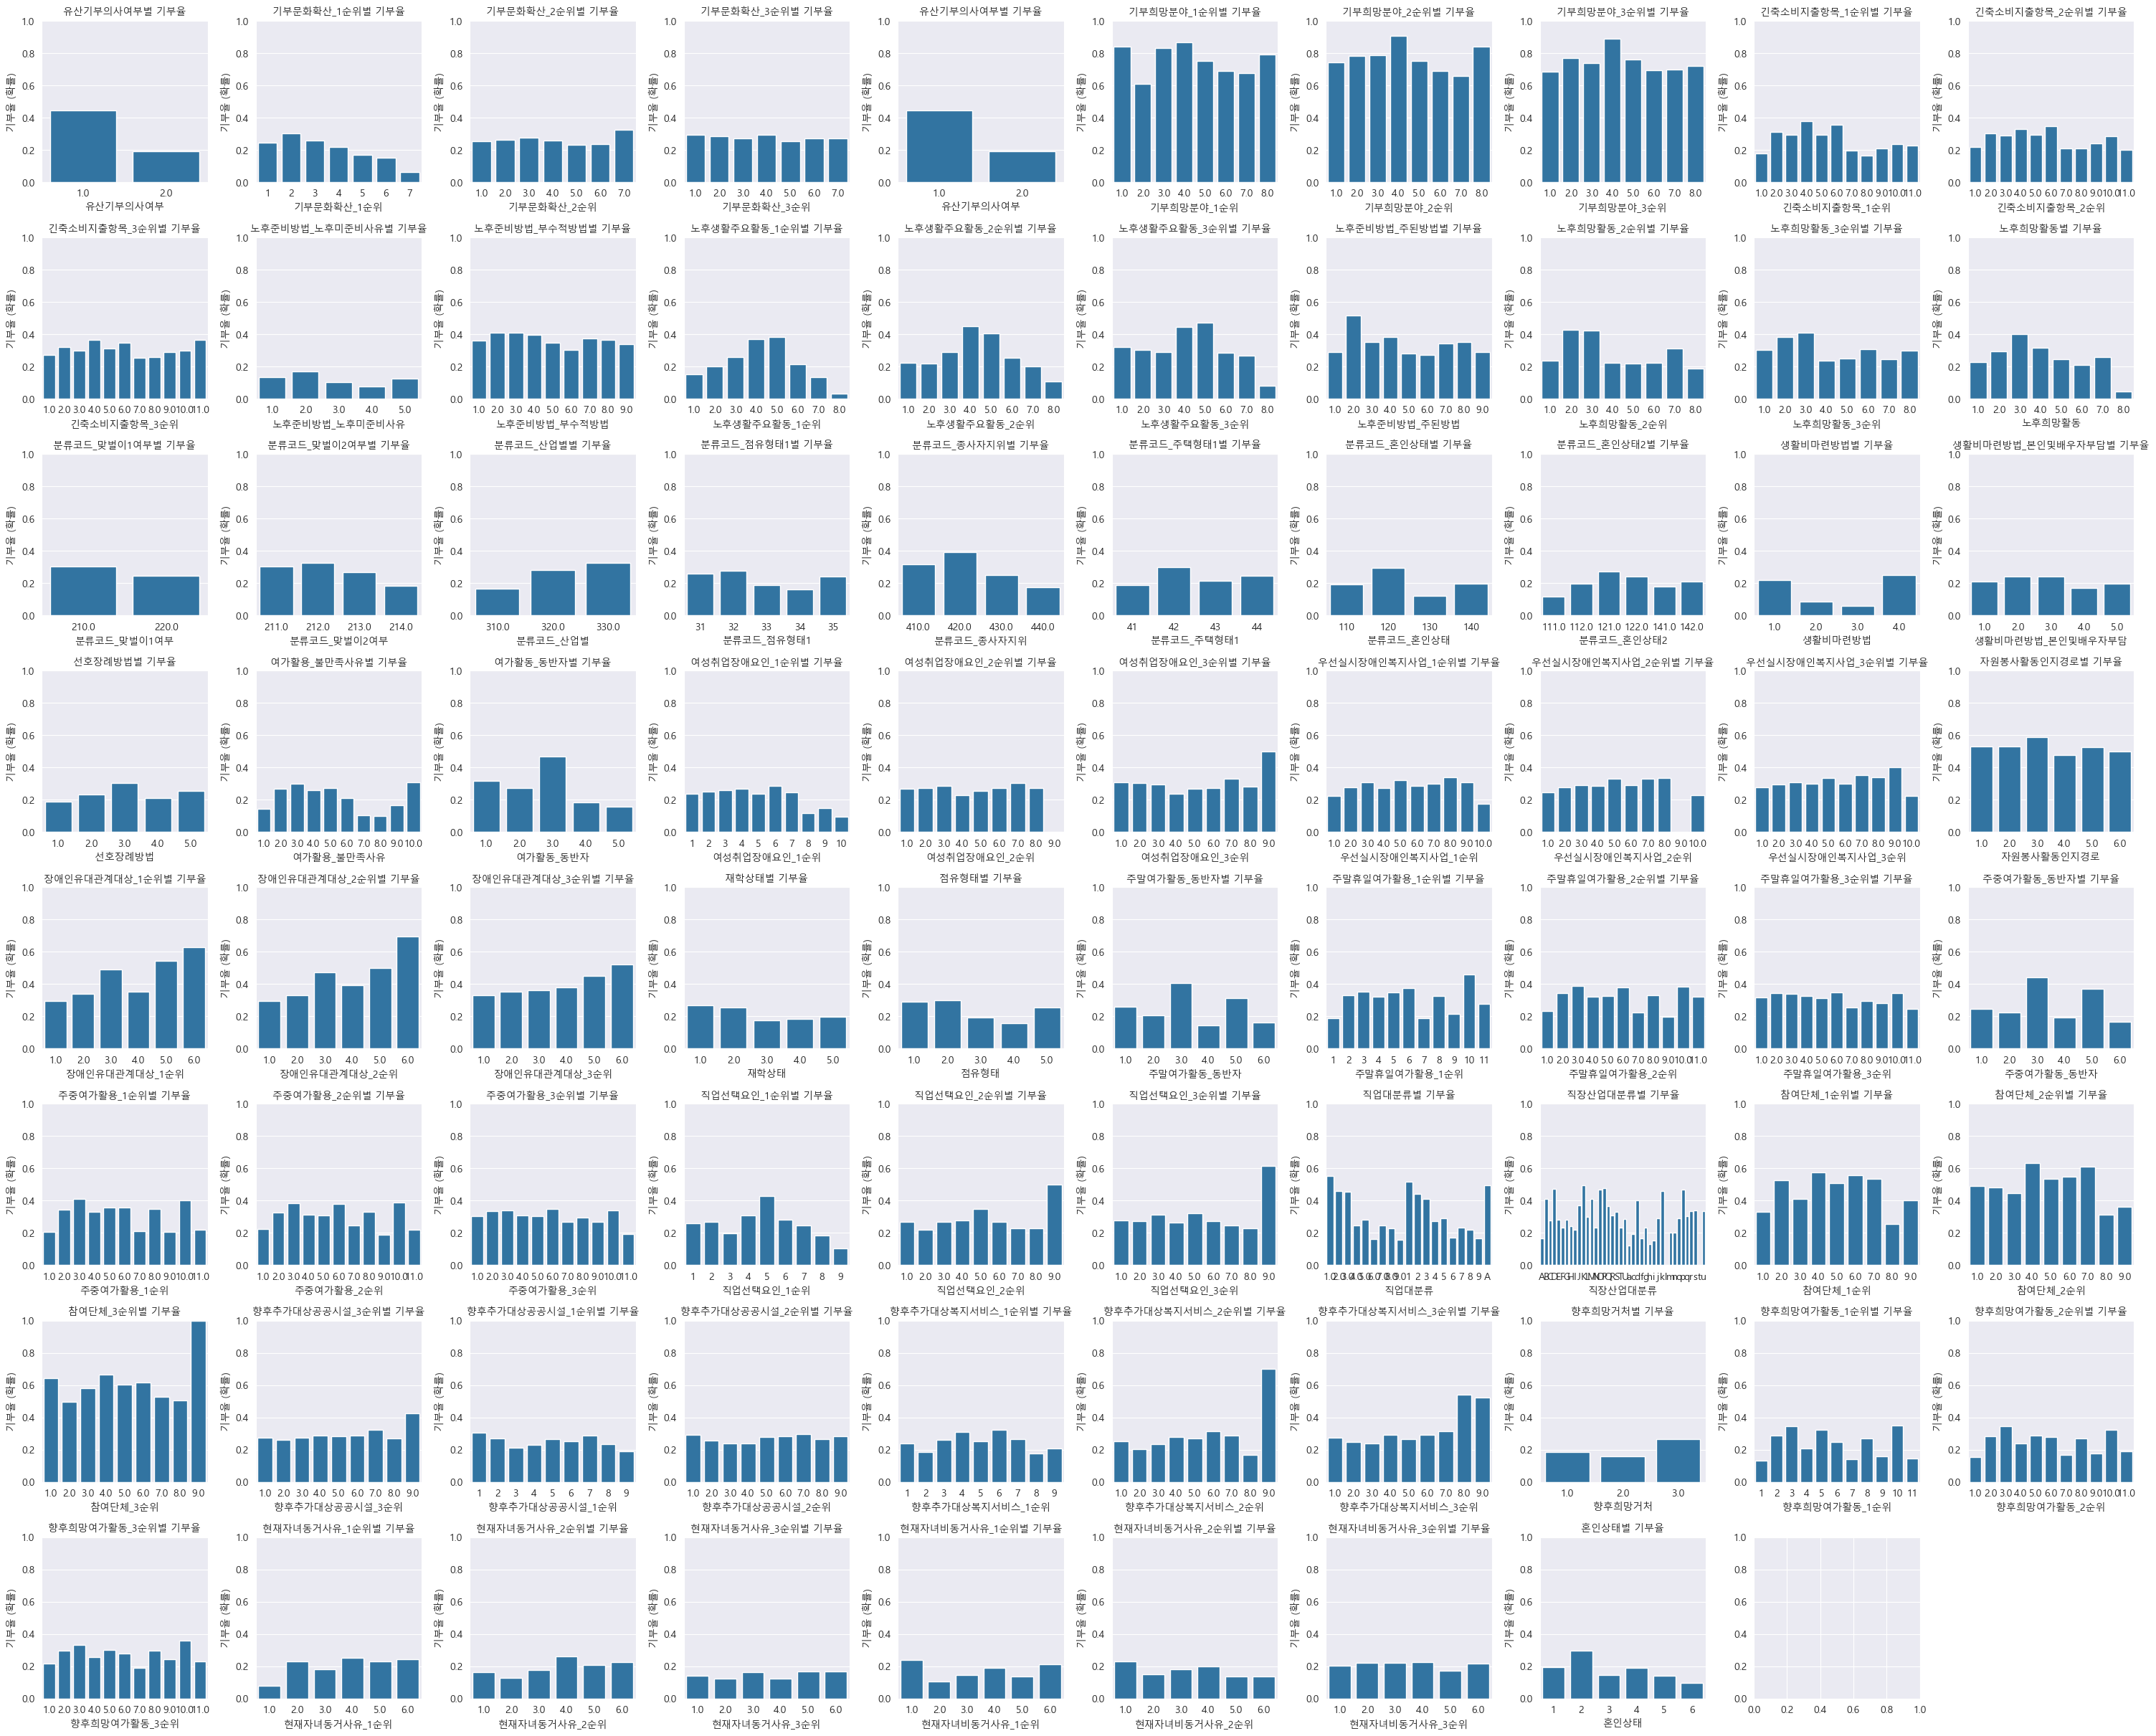

In [22]:
n_cols = 10  # 한 줄에 10개
n_rows = (len(nominal_cols_original) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

i=0
for _, col in enumerate(nominal_cols_original):
    if col in df.columns and col != '기부여부':

        # 각 범주별 기부율 계산
        rate = df.groupby(col)['기부여부'].mean().reset_index()

        # barplot (기부율)
        sns.barplot(x=col, y='기부여부', data=rate, ax=axes[i])
        axes[i].set_title(f"{col}별 기부율", fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("기부율 (확률)")
        axes[i].set_ylim(0, 1)  # 0~1 사이 확률로 고정
        i+=1

# 남은 subplot 제거
for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

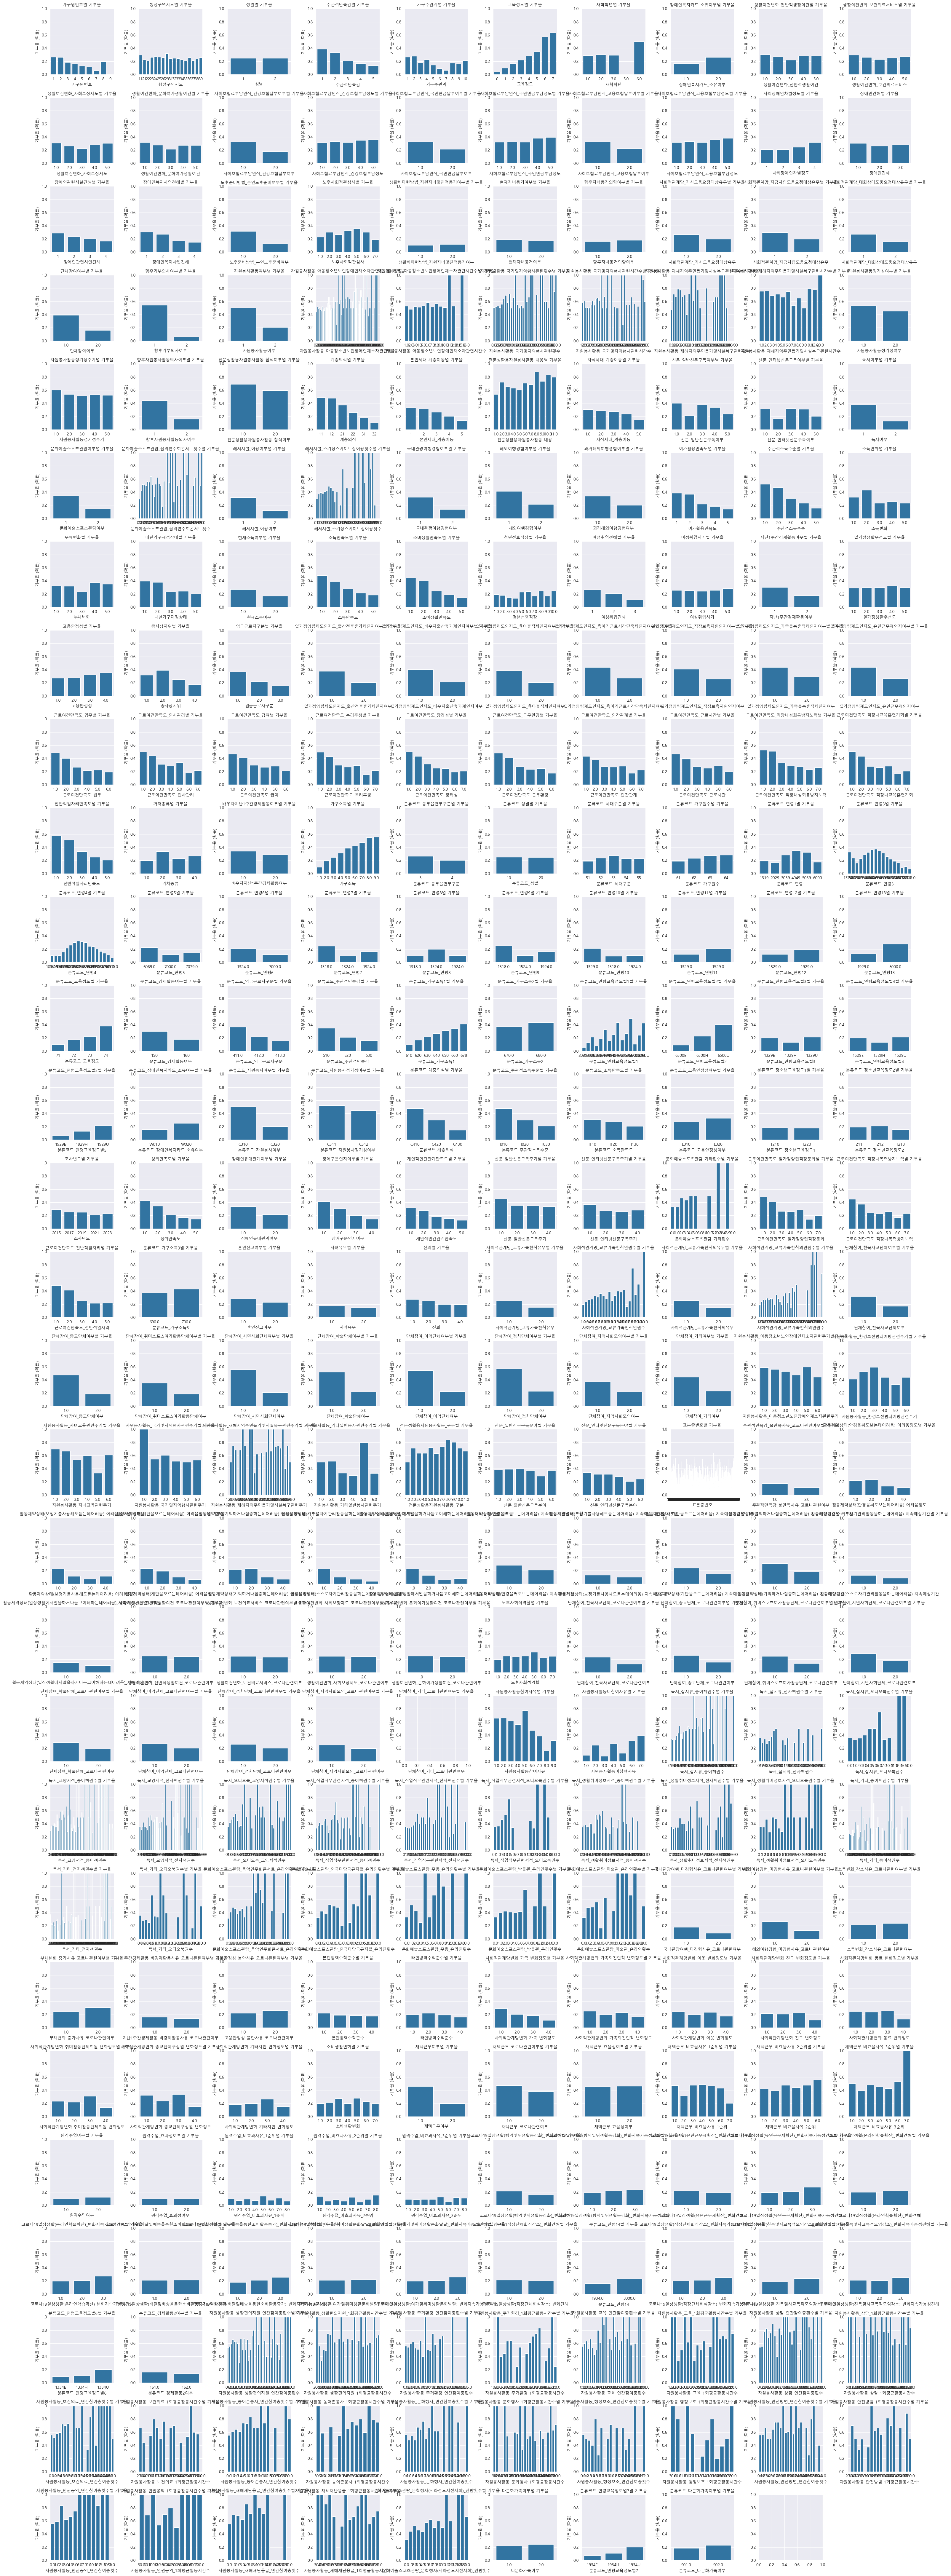

In [37]:
n_cols = 10  # 한 줄에 10개
n_rows = (len(ordinal_cols_original) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

i=0
for _, col in enumerate(ordinal_cols_original):
    if col in df.columns and col != '기부여부':

        # 각 범주별 기부율 계산
        rate = df.groupby(col)['기부여부'].mean().reset_index()

        # barplot (기부율)
        sns.barplot(x=col, y='기부여부', data=rate, ax=axes[i])
        axes[i].set_title(f"{col}별 기부율", fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("기부율 (확률)")
        axes[i].set_ylim(0, 1)  # 0~1 사이 확률로 고정
        i+=1

# 남은 subplot 제거
for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [51]:
# 결측치 비율이 50% 이상인 컬럼 제거
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop = missing_ratio[missing_ratio >= 0.5].index.tolist()

print(f"50% 이상 결측치를 가진 컬럼들: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# 컬럼 리스트 업데이트 (제거된 컬럼들 반영)
numeric_cols = [col for col in numeric_cols_original if col in df.columns]
nominal_cols = [col for col in nominal_cols_original if col in df.columns]
ordinal_cols = [col for col in ordinal_cols_original if col in df.columns]

print(f"전처리 후 데이터 형태: {df.shape}")

50% 이상 결측치를 가진 컬럼들: ['재학학년', '사회보험료부담인식_건강보험부담정도', '사회보험료부담인식_국민연금부담정도', '사회보험료부담인식_고용보험부담정도', '장애인견해', '노후준비방법_부수적방법', '노후준비방법_노후미준비사유', '생활비마련방법', '생활비마련방법_본인및배우자부담', '생활비마련방법_지원자녀및친척동거여부', '현재자녀동거여부', '현재자녀동거사유_1순위', '현재자녀동거사유_2순위', '현재자녀동거사유_3순위', '현재자녀비동거사유_1순위', '현재자녀비동거사유_2순위', '현재자녀비동거사유_3순위', '향후자녀동거의향여부', '향후희망거처', '사회적관계망_자금차입도움요청대상인원수', '단체참여여부', '참여단체_1순위', '참여단체_2순위', '참여단체_3순위', '기부희망분야_1순위', '기부희망분야_2순위', '기부희망분야_3순위', '자원봉사활동_아동청소년노인장애인재소자관련횟수', '자원봉사활동_아동청소년노인장애인재소자관련시간수', '자원봉사활동_환경보전범죄예방관련횟수', '자원봉사활동_환경보전범죄예방관련시간수', '자원봉사활동_자녀교육관련횟수', '자원봉사활동_자녀교육관련시간수', '자원봉사활동_국가및지역행사관련횟수', '자원봉사활동_국가및지역행사관련시간수', '자원봉사활동_재해지역주민돕기및시설복구관련횟수', '자원봉사활동_재해지역주민돕기및시설복구관련시간수', '자원봉사활동_기타일반봉사관련횟수', '자원봉사활동_기타일반봉사관련시간수', '자원봉사활동정기성여부', '자원봉사활동정기성주기', '자원봉사활동인지경로', '전문성활용자원봉사활동_참석여부', '전문성활용자원봉사활동_내용', '독서_잡지류권수', '독서_교양서적권수', '독서_직업직무관련서적권수', '독서_생활취미정보서적권수', '독서_기타권수', '문화예술스포츠관람_음악연주회콘서트횟수', '문화예술스포츠관람_연극마당극뮤지컬횟수', '문화예술스포츠관람_무용횟수', '문화예술스포츠관람_영화횟수', '문화예술스포츠관람_박물관횟수', '문화예술스포츠관람_미술관횟수',

In [52]:
# 데이터 복사본 생성
df_processed = df.copy()

# Numeric 컬럼: 최빈값으로 결측치 채우기
for col in df_processed.columns:
    if  df_processed[col].isnull().sum() > 0:
        mode_value = df_processed[col].mode()[0] if not df_processed[col].mode().empty else df_processed[col].median()
        df_processed[col].fillna(mode_value, inplace=True)
        print(f"{col}: 최빈값 {mode_value}로 결측치 {df[col].isnull().sum()}개 채움")
#
# # Nominal과 Ordinal 컬럼: Random Forest로 결측치 예측
# def fill_missing_with_rf(df, target_col, feature_cols, is_numeric=False):
#     """Random Forest를 사용하여 결측치 채우기"""
#     # 결측치가 없는 행과 있는 행 분리
#     train_mask = df[target_col].notna()
#     missing_mask = df[target_col].isna()
#
#     if missing_mask.sum() == 0:
#         return df[target_col]
#
#     # 특성 데이터 준비
#     X_all = df[feature_cols].copy()
#
#     # 모든 컬럼을 수치형으로 변환 (임시 인코딩)
#     temp_encoders = {}
#     for col in X_all.columns:
#         if X_all[col].dtype == 'object':
#             # 문자열 컬럼을 라벨 인코딩
#             from sklearn.preprocessing import LabelEncoder
#             le = LabelEncoder()
#
#             # 결측치를 임시로 'missing'으로 채움
#             X_all[col] = X_all[col].fillna('missing')
#             X_all[col] = le.fit_transform(X_all[col].astype(str))
#             temp_encoders[col] = le
#         else:
#             # 수치형 컬럼의 결측치를 중앙값으로 채움
#             X_all[col] = X_all[col].fillna(X_all[col].median())
#
#     # 훈련 데이터와 예측할 데이터 분리
#     X_train = X_all.loc[train_mask]
#     X_missing = X_all.loc[missing_mask]
#
#     # 타겟 값 (결측치가 아닌 데이터만)
#     y_train = df.loc[train_mask, target_col]
#
#     # 타겟도 문자열이면 인코딩
#     if y_train.dtype == 'object':
#         target_encoder = LabelEncoder()
#         y_train_encoded = target_encoder.fit_transform(y_train.astype(str))
#     else:
#         y_train_encoded = y_train
#         target_encoder = None
#
#     # Random Forest 모델 학습
#     if is_numeric:
#         from sklearn.ensemble import RandomForestRegressor
#         rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
#     else:
#         from sklearn.ensemble import RandomForestClassifier
#         rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
#
#     rf_model.fit(X_train, y_train_encoded)
#
#     # 예측
#     predictions = rf_model.predict(X_missing)
#
#     # 타겟이 문자열이었다면 다시 디코딩
#     if target_encoder is not None:
#         predictions = target_encoder.inverse_transform(predictions.astype(int))
#
#     # 결과 반영
#     result = df[target_col].copy()
#     result.loc[missing_mask] = predictions
#
#     return result
#
# # 사용할 특성 컬럼들 (타겟 컬럼과 현재 처리 중인 컬럼 제외)
# all_feature_columns = [col for col in df_processed.columns if col != target_col]
#
# # Nominal 컬럼 결측치 처리
# for col in nominal_cols:
#     if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
#         print(f"{col}: RF로 결측치 {df_processed[col].isnull().sum()}개 처리 중...")
#         feature_cols = [c for c in all_feature_columns if c != col]
#         df_processed[col] = fill_missing_with_rf(df_processed, col, feature_cols, is_numeric=False)
#
# # Ordinal 컬럼 결측치 처리
# for col in ordinal_cols:
#     if col in df_processed.columns and df_processed[col].isnull().sum() > 0:
#         print(f"{col}: RF로 결측치 {df_processed[col].isnull().sum()}개 처리 중...")
#         feature_cols = [c for c in all_feature_columns if c != col]
#         df_processed[col] = fill_missing_with_rf(df_processed, col, feature_cols, is_numeric=False)
#
# print("결측치 처리 완료!")
# print(f"처리 후 결측치: {df_processed.isnull().sum().sum()}")

# 결측치 현황 확인
if df_processed.isnull().sum().sum() > 0:
    print("남은 결측치:")
    print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

재학상태: 최빈값 1.0로 결측치 7360개 채움
장애인복지카드_소유여부: 최빈값 2.0로 결측치 36423개 채움
생활여건변화_전반적생활여건: 최빈값 3.0로 결측치 12202개 채움
생활여건변화_보건의료서비스: 최빈값 2.0로 결측치 12202개 채움
생활여건변화_사회보장제도: 최빈값 3.0로 결측치 12202개 채움
생활여건변화_문화여가생활여건: 최빈값 3.0로 결측치 12202개 채움
사회보험료부담인식_건강보험납부여부: 최빈값 1.0로 결측치 46416개 채움
사회보험료부담인식_국민연금납부여부: 최빈값 2.0로 결측치 46416개 채움
사회보험료부담인식_고용보험납부여부: 최빈값 2.0로 결측치 46416개 채움
향후추가대상공공시설_2순위: 최빈값 3.0로 결측치 14957개 채움
향후추가대상공공시설_3순위: 최빈값 2.0로 결측치 51856개 채움
향후추가대상복지서비스_2순위: 최빈값 2.0로 결측치 15226개 채움
향후추가대상복지서비스_3순위: 최빈값 5.0로 결측치 49952개 채움
선호장례방법: 최빈값 2.0로 결측치 12202개 채움
우선실시장애인복지사업_1순위: 최빈값 2.0로 결측치 53125개 채움
우선실시장애인복지사업_2순위: 최빈값 2.0로 결측치 60648개 채움
우선실시장애인복지사업_3순위: 최빈값 2.0로 결측치 82056개 채움
노후준비방법_본인노후준비여부: 최빈값 1.0로 결측치 12202개 채움
노후준비방법_주된방법: 최빈값 1.0로 결측치 70309개 채움
노후사회적관심사: 최빈값 1.0로 결측치 79898개 채움
노후희망활동: 최빈값 1.0로 결측치 12202개 채움
사회적관계망_가사도움요청대상유무: 최빈값 1.0로 결측치 10818개 채움
사회적관계망_가사도움요청대상인원수: 최빈값 1.0로 결측치 52591개 채움
사회적관계망_대화상대도움요청대상인원수: 최빈값 1.0로 결측치 35384개 채움
유산기부의사여부: 최빈값 2.0로 결측치 73906개 채움
기부문화확산_2순위: 최빈값 3.0로 결측치 20802개 채움
기부문

In [53]:
# 전처리된 데이터 저장
df_processed.to_csv('preprocessed_data_2-2.csv', index=False, encoding='utf-8-sig')
print("전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.")

전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.


In [54]:
# 데이터 복사본 생성
df_encoded = df_processed.copy()

# Nominal 컬럼: 더미변수화 (숫자+문자 혼합 처리)
nominal_cols.remove('기부여부')
nominal_dummies = []
for col in nominal_cols:
    if col in df_encoded.columns:
        # 숫자와 문자가 섞인 경우를 대비해 모두 문자열로 변환
        df_encoded[col] = df_encoded[col].astype(str)

        # 더미변수 생성
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        nominal_dummies.append(dummies)

        # 원본 컬럼 제거
        df_encoded = df_encoded.drop(columns=[col])

        print(f"{col}: 더미변수 {len(dummies.columns)}개 생성")

# 더미변수들을 원본 데이터프레임에 결합
if nominal_dummies:
    df_encoded = pd.concat([df_encoded] + nominal_dummies, axis=1)

# Ordinal 컬럼: 라벨 인코딩
label_encoders = {}
for col in ordinal_cols:
    if col in df_encoded.columns:
        # 숫자와 문자가 섞인 경우를 대비해 문자열로 변환 후 인코딩
        df_encoded[col] = df_encoded[col].astype(str)

        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

        print(f"{col}: 라벨 인코딩 완료 ({len(le.classes_)}개 클래스)")

print(f"인코딩 후 데이터 형태: {df_encoded.shape}")

유산기부의사여부: 더미변수 1개 생성
기부문화확산_1순위: 더미변수 6개 생성
기부문화확산_2순위: 더미변수 6개 생성
기부문화확산_3순위: 더미변수 6개 생성
긴축소비지출항목_1순위: 더미변수 10개 생성
노후준비방법_주된방법: 더미변수 8개 생성
노후희망활동: 더미변수 7개 생성
분류코드_맞벌이1여부: 더미변수 1개 생성
분류코드_맞벌이2여부: 더미변수 3개 생성
분류코드_산업별: 더미변수 2개 생성
분류코드_점유형태1: 더미변수 4개 생성
분류코드_종사자지위: 더미변수 3개 생성
분류코드_주택형태1: 더미변수 3개 생성
분류코드_혼인상태: 더미변수 3개 생성
선호장례방법: 더미변수 4개 생성
여성취업장애요인_1순위: 더미변수 9개 생성
여성취업장애요인_2순위: 더미변수 8개 생성
여성취업장애요인_3순위: 더미변수 8개 생성
우선실시장애인복지사업_1순위: 더미변수 9개 생성
우선실시장애인복지사업_2순위: 더미변수 9개 생성
우선실시장애인복지사업_3순위: 더미변수 9개 생성
재학상태: 더미변수 4개 생성
점유형태: 더미변수 4개 생성
주말여가활동_동반자: 더미변수 5개 생성
주말휴일여가활용_1순위: 더미변수 10개 생성
주말휴일여가활용_2순위: 더미변수 10개 생성
주말휴일여가활용_3순위: 더미변수 10개 생성
주중여가활동_동반자: 더미변수 5개 생성
주중여가활용_1순위: 더미변수 10개 생성
주중여가활용_2순위: 더미변수 10개 생성
직업선택요인_1순위: 더미변수 8개 생성
직업선택요인_2순위: 더미변수 8개 생성
직업선택요인_3순위: 더미변수 8개 생성
직업대분류: 더미변수 18개 생성
직장산업대분류: 더미변수 39개 생성
향후추가대상공공시설_3순위: 더미변수 8개 생성
향후추가대상공공시설_1순위: 더미변수 8개 생성
향후추가대상공공시설_2순위: 더미변수 8개 생성
향후추가대상복지서비스_1순위: 더미변수 8개 생성
향후추가대상복지서비스_2순위: 더미변수 8개 생성
향후추가대상복지서비스_3순위: 더미변수 8개 생성
향후희망여가활동_1순위: 더미변수 10개 

In [55]:
# df_encoded: 이미 모든 더미 컬럼과 라벨 인코딩 컬럼 포함
# nominal_cols: 원래 더미화한 컬럼 리스트
# ordinal_cols: 원래 라벨인코딩한 컬럼 리스트

# 1️⃣ 더미 변수 추출
dummy_columns = []
for col in nominal_cols:
    # df_encoded 컬럼 중 원래 컬럼명으로 시작하는 것만 선택
    dummy_columns += [c for c in df_encoded.columns if c.startswith(col + "_")]

print("더미 변수 컬럼:")
print(dummy_columns)

# 2️⃣ 라벨인코딩 컬럼 추출
label_columns = [c for c in df_encoded.columns if c in ordinal_cols]
print("라벨인코딩 컬럼:")
print(label_columns)


더미 변수 컬럼:
['유산기부의사여부_2.0', '기부문화확산_1순위_2', '기부문화확산_1순위_3', '기부문화확산_1순위_4', '기부문화확산_1순위_5', '기부문화확산_1순위_6', '기부문화확산_1순위_7', '기부문화확산_2순위_2.0', '기부문화확산_2순위_3.0', '기부문화확산_2순위_4.0', '기부문화확산_2순위_5.0', '기부문화확산_2순위_6.0', '기부문화확산_2순위_7.0', '기부문화확산_3순위_2.0', '기부문화확산_3순위_3.0', '기부문화확산_3순위_4.0', '기부문화확산_3순위_5.0', '기부문화확산_3순위_6.0', '기부문화확산_3순위_7.0', '유산기부의사여부_2.0', '긴축소비지출항목_1순위_10.0', '긴축소비지출항목_1순위_11.0', '긴축소비지출항목_1순위_2.0', '긴축소비지출항목_1순위_3.0', '긴축소비지출항목_1순위_4.0', '긴축소비지출항목_1순위_5.0', '긴축소비지출항목_1순위_6.0', '긴축소비지출항목_1순위_7.0', '긴축소비지출항목_1순위_8.0', '긴축소비지출항목_1순위_9.0', '노후준비방법_주된방법_2.0', '노후준비방법_주된방법_3.0', '노후준비방법_주된방법_4.0', '노후준비방법_주된방법_5.0', '노후준비방법_주된방법_6.0', '노후준비방법_주된방법_7.0', '노후준비방법_주된방법_8.0', '노후준비방법_주된방법_9.0', '노후희망활동_2.0', '노후희망활동_3.0', '노후희망활동_4.0', '노후희망활동_5.0', '노후희망활동_6.0', '노후희망활동_7.0', '노후희망활동_8.0', '분류코드_맞벌이1여부_220.0', '분류코드_맞벌이2여부_212.0', '분류코드_맞벌이2여부_213.0', '분류코드_맞벌이2여부_214.0', '분류코드_산업별_320.0', '분류코드_산업별_330.0', '분류코드_점유형태1_32', '분류코드_점유형태1_33', '분류코드_점유형태1_34', '분류코드_점유형태1_35', '분류코드

In [56]:
# 특성과 타겟 분리
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# train/validation/test 분할 (60:20:20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print(f"Train 데이터: {X_train.shape}")
print(f"Validation 데이터: {X_valid.shape}")
print(f"Test 데이터: {X_test.shape}")
print(f"타겟 분포 - Train: {y_train.value_counts().to_dict()}")
print(f"타겟 분포 - Valid: {y_valid.value_counts().to_dict()}")
print(f"타겟 분포 - Test: {y_test.value_counts().to_dict()}")

Train 데이터: (110949, 443)
Validation 데이터: (36983, 443)
Test 데이터: (36983, 443)
타겟 분포 - Train: {0: 83333, 1: 27616}
타겟 분포 - Valid: {0: 27778, 1: 9205}
타겟 분포 - Test: {0: 27778, 1: 9205}


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler

In [58]:
# 각종 모델 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin

In [60]:
#for scale_pos_weight for xgb
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg / pos) if pos > 0 else 1.0

In [61]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42, class_weight='balanced',
                                            min_samples_split=5,min_samples_leaf=4,bootstrap=True),
    "XGBoost": xgb.XGBClassifier(max_depth=4, learning_rate=0.1, n_estimators=100,
             subsample=0.8, colsample_bytree=0.8, min_child_weight=5, n_jobs=-1, scale_pos_weight=scale_pos_weight,
                                max_bin=255, tree_method='hist', eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, num_leaves=7, subsample=0.8,
                                colsample_bytree=0.8, min_child_samples=10, random_state=42, n_jobs=2, scale_pos_weight=scale_pos_weight,
                               class_weight='balanced', max_bin=255, force_col_wise=True, boosting_type='gbdt' ),
    "CatBoost": CatBoostClassifier(depth=2, learning_rate=0.15, iterations=50, verbose=0, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(32,), max_iter=150, learning_rate_init=0.01, random_state=42, solver='adam',
                                 early_stopping=True, activation='relu', alpha=1e-3
    ),
}

In [62]:
# 1. PyTorch 1D CNN 모델 정의
class CNN1D(nn.Module):
    def __init__(self, input_channels, input_length):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)

        conv_output_size = ((input_length - 2) // 2 - 2) // 2 * 64
        self.fc1 = nn.Linear(conv_output_size, 64)
        self.dropout = nn.Dropout(0.3)  # 드롭아웃 줄임 (0.5 → 0.3)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# 래퍼 클래스에서 weight decay만 추가
class CNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_channels=1, input_length=179, epochs=15, batch_size=64, lr=0.0005, device='cpu'):
        self.input_channels = input_channels
        self.input_length = input_length
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = device

        self.model = CNN1D(input_channels, input_length).to(self.device)
        self.criterion = nn.BCELoss()
        # weight_decay 추가로 정규화
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-4)

    def fit(self, X, y):
        if hasattr(y, "to_numpy"):
          y = y.to_numpy()

        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(self.device)

        dataset = TensorDataset(X, y)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                self.optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                loss.backward()
                self.optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            outputs = self.model(X).cpu().numpy()
        return np.hstack([1 - outputs, outputs])  # 클래스 0,1 확률

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [63]:
def evaluate_model(y_true, y_pred, y_prob, algorithm_name, dataset_name="Test"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = (recall + specificity) / 2
    auc = roc_auc_score(y_true, y_prob)

    return {
        'Dataset': dataset_name,
        'Algorithm': algorithm_name,
        'N': len(y_true),
        'True Positive': tp,
        'True Negative': tn,
        'False Positive': fp,
        'False Negative': fn,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-score': f1,
        'Accuracy': accuracy,
        'Balanced Accuracy': balanced_accuracy,
        'AUC': auc
    }

In [64]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
THRESHOLD = 0.3
results = []

## cuda 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("현재 사용되고 있는 device: ", device)

# 3. 데이터 차원 변환 (PyTorch CNN 1D 입력은 [배치, 채널, 길이])
X_train_cnn = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_cnn = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

cnn_model = CNNClassifier(input_channels=1, input_length=X_train.shape[1], epochs=20, batch_size=32, device=device)
models['1D CNN PyTorch'] =  cnn_model

## 모델별 학습
for name, model in models.items():
    fold_metrics = []
    print(f"model name: {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Use .iloc for pandas DataFrames with integer indices
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # StandardScaler 적용
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        # DataFrame 형태로 변환 (컬럼명 유지)
        X_tr_scaled = pd.DataFrame(X_tr_scaled, columns=X_tr.columns, index=X_tr.index)
        X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

        if name == '1D CNN PyTorch':
            # Convert to numpy arrays and reshape for CNN (스케일링된 데이터 사용)
            X_tr_cnn = X_tr_scaled.values.reshape((X_tr_scaled.shape[0], 1, X_tr_scaled.shape[1]))
            X_val_cnn = X_val_scaled.values.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))

            # Create fresh CNN instance for each fold
            cnn_model = CNNClassifier(
                input_channels=1,
                input_length=X_train.shape[1],
                epochs=20,
                batch_size=64,
                lr=0.0005,
                device=device
            )
            cnn_model.fit(X_tr_cnn, y_tr.values)
            y_pred = cnn_model.predict(X_val_cnn)
            y_prob = cnn_model.predict_proba(X_val_cnn)[:, 1]
            y_pred = (y_prob >= THRESHOLD).astype(int)

            # Clear GPU memory if using CUDA
            if device == 'cuda':
                torch.cuda.empty_cache()

        else:
            clf = clone(model)
            # 스케일링된 데이터로 학습
            clf.fit(X_tr_scaled, y_tr)

            # Handle probability prediction (스케일링된 데이터로 예측)
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_val_scaled)[:, 1]
                y_pred = (y_prob >= THRESHOLD).astype(int)
            else:
                # Fallback to decision function for models like SVM
                y_prob = clf.decision_function(X_val_scaled)
                if y_prob.max() != y_prob.min():
                    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
                else:
                    y_prob = np.full_like(y_prob, 0.5)
                # 커스텀 threshold로 예측 변환
                y_pred = (y_prob >= THRESHOLD).astype(int)

        fold_result = evaluate_model(y_val, y_pred, y_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1}")
        fold_metrics.append(fold_result)

    # Calculate average metrics across folds
    avg_result = {}
    numeric_keys = ['N', 'True Positive', 'True Negative', 'False Positive', 'False Negative',
                    'Precision', 'Recall', 'Specificity', 'F1-score', 'Accuracy',
                    'Balanced Accuracy', 'AUC']

    for key in numeric_keys:
        avg_result[key] = np.mean([res[key] for res in fold_metrics])

    avg_result['Algorithm'] = name
    results.append(avg_result)

현재 사용되고 있는 device:  cuda
model name: Logistic Regression
model name: Random Forest
model name: XGBoost
model name: LightGBM
[LightGBM] [Info] Number of positive: 18411, number of negative: 55555
[LightGBM] [Info] Total Bins 1691
[LightGBM] [Info] Number of data points in the train set: 73966, number of used features: 426
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

In [65]:
df_fold_results = pd.DataFrame(results).round(6)
display(df_fold_results)

,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC,Algorithm
0,36983.0,7336.666667,22793.333333,4984.333333,1868.666667,0.595473,0.797002,0.820563,0.681652,0.814699,0.808782,0.881188,Logistic Regression
1,36983.0,8513.333333,17119.333333,10658.333333,692.000000,0.444101,0.924826,0.616299,0.600044,0.693093,0.770562,0.875646,Random Forest
2,36983.0,8289.666667,19279.000000,8498.666667,915.666667,0.493780,0.900528,0.694047,0.637823,0.745442,0.797288,0.883363,XGBoost
3,36983.0,9045.666667,7893.666667,19884.000000,159.666667,0.312705,0.982655,0.284173,0.474424,0.458030,0.633414,0.875407,LightGBM
4,36983.0,7607.666667,22026.666667,5751.000000,1597.666667,0.569496,0.826441,0.792963,0.674317,0.801296,0.809702,0.877884,CatBoost
5,36983.0,7044.333333,22807.333333,4970.333333,2161.000000,0.586275,0.765244,0.821067,0.663890,0.807173,0.793156,0.868858,MLP
6,36983.0,7241.000000,22686.666667,5091.000000,1964.333333,0.587238,0.786609,0.816723,0.672402,0.809228,0.801666,0.875427,1D CNN PyTorch


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
# torch 관련 import는 이 코드 블록에서 생략했습니다. 원래 코드에 맞게 유지해주세요.

# ... (이전 코드 생략: n_splits, skf, THRESHOLD, results, device, X_train_cnn, X_test_cnn, cnn_model, models 정의 부분)
# models 딕셔너리와 CNNClassifier, evaluate_model 함수는 정의되어 있다고 가정합니다.
THRESHOLD = 0.4

## 모델별 학습
for name, model in models.items():
    fold_metrics = []
    print(f"model name: {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        # Use .iloc for pandas DataFrames with integer indices
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # StandardScaler 적용
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        # DataFrame 형태로 변환 (컬럼명 유지)
        X_tr_scaled = pd.DataFrame(X_tr_scaled, columns=X_tr.columns, index=X_tr.index)
        X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

        if name == '1D CNN PyTorch':
            # Convert to numpy arrays and reshape for CNN (스케일링된 데이터 사용)
            X_tr_cnn = X_tr_scaled.values.reshape((X_tr_scaled.shape[0], 1, X_tr_scaled.shape[1]))
            X_val_cnn = X_val_scaled.values.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))

            # Create fresh CNN instance for each fold
            cnn_model = CNNClassifier(
                input_channels=1,
                input_length=X_train.shape[1],
                epochs=20,
                batch_size=64,
                lr=0.0005,
                device=device
            )
            cnn_model.fit(X_tr_cnn, y_tr.values)

            # ------------------------------------------------------------------
            # 💡 훈련 스코어 출력 추가 (1D CNN PyTorch)
            y_tr_prob = cnn_model.predict_proba(X_tr_cnn)[:, 1]
            y_tr_pred = (y_tr_prob >= THRESHOLD).astype(int)
            train_result = evaluate_model(y_tr, y_tr_pred, y_tr_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1} Training")
            print(f"[{name}] Fold {fold+1} 훈련 스코어 (Accuracy/AUC): {train_result['Accuracy']:.4f} / {train_result['AUC']:.4f}")
            # ------------------------------------------------------------------

            y_prob = cnn_model.predict_proba(X_val_cnn)[:, 1]
            y_pred = (y_prob >= THRESHOLD).astype(int)

            # Clear GPU memory if using CUDA
            if device == 'cuda':
                torch.cuda.empty_cache()

        else:
            clf = clone(model)
            # 스케일링된 데이터로 학습
            clf.fit(X_tr_scaled, y_tr)

            # ------------------------------------------------------------------
            # 💡 훈련 스코어 출력 추가 (다른 모델들)
            if hasattr(clf, 'predict_proba'):
                y_tr_prob = clf.predict_proba(X_tr_scaled)[:, 1]
                y_tr_pred = (y_tr_prob >= THRESHOLD).astype(int)
            else:
                # decision_function 대체 로직
                y_tr_prob = clf.decision_function(X_tr_scaled)
                if y_tr_prob.max() != y_tr_prob.min():
                    y_tr_prob = (y_tr_prob - y_tr_prob.min()) / (y_tr_prob.max() - y_tr_prob.min())
                else:
                    y_tr_prob = np.full_like(y_tr_prob, 0.5)
                y_tr_pred = (y_tr_prob >= THRESHOLD).astype(int)

            train_result = evaluate_model(y_tr, y_tr_pred, y_tr_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1} Training")
            print(f"[{name}] Fold {fold+1} 훈련 스코어 (precision/recall/f1): {fold_result['Precision']:.4f} / {fold_result['Recall']:.4f} / {fold_result['F1-score']:.4f}")
            # ------------------------------------------------------------------

            # Handle probability prediction (스케일링된 데이터로 예측) - 검증 데이터
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_val_scaled)[:, 1]
                y_pred = (y_prob >= THRESHOLD).astype(int)
            else:
                # Fallback to decision function for models like SVM
                y_prob = clf.decision_function(X_val_scaled)
                if y_prob.max() != y_prob.min():
                    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
                else:
                    y_prob = np.full_like(y_prob, 0.5)
                # 커스텀 threshold로 예측 변환
                y_pred = (y_prob >= THRESHOLD).astype(int)

        # 검증 스코어 계산 및 저장 (기존 로직 유지)
        fold_result = evaluate_model(y_val, y_pred, y_prob,
                                   algorithm_name=name,
                                   dataset_name=f"Fold {fold+1} Validation")
        fold_metrics.append(fold_result)
        # 검증 스코어도 함께 출력 (선택 사항)
        print(f"[{name}] Fold {fold+1} 검증 스코어 (precision/recall/f1): {fold_result['Precision']:.4f} / {fold_result['Recall']:.4f} / {fold_result['F1-score']:.4f}")


    # Calculate average metrics across folds (기존 로직 유지)
    avg_result = {}
    numeric_keys = ['N', 'True Positive', 'True Negative', 'False Positive', 'False Negative',
                    'Precision', 'Recall', 'Specificity', 'F1-score', 'Accuracy',
                    'Balanced Accuracy', 'AUC']

    for key in numeric_keys:
        avg_result[key] = np.mean([res[key] for res in fold_metrics])

    avg_result['Algorithm'] = name
    results.append(avg_result)
    print("-" * 50)
    print(f"[{name}] 평균 검증 Accuracy: {avg_result['Accuracy']:.4f}, 평균 검증 AUC: {avg_result['AUC']:.4f}")
    print("-" * 50)
    # ------------------------------------------------------------------
    # 💡 2. 최종 모델 학습 및 X_test 평가 (진짜 테스트 결과)
    # ------------------------------------------------------------------

    # 1. 최종 모델 재훈련 (전체 X_train 데이터 사용)
    print(f"\n===== {name} 최종 모델 재훈련 및 X_test 평가 시작 =====")

    # 훈련 데이터 전체에 대한 스케일러 적용 (X_train과 X_test 모두에 적용)
    final_scaler = StandardScaler()
    X_train_final_scaled = final_scaler.fit_transform(X_train)
    # X_test_final_scaled: 훈련 데이터셋의 통계로 스케일링된 테스트 데이터
    X_test_final_scaled = final_scaler.transform(X_test)

    # DataFrame 형태로 변환
    X_train_final_scaled = pd.DataFrame(X_train_final_scaled, columns=X_train.columns)
    X_test_final_scaled = pd.DataFrame(X_test_final_scaled, columns=X_test.columns)

    if name == '1D CNN PyTorch':
        # CNN은 numpy 배열로 reshape 필요
        X_train_final_cnn = X_train_final_scaled.values.reshape((X_train_final_scaled.shape[0], 1, X_train_final_scaled.shape[1]))
        X_test_final_cnn = X_test_final_scaled.values.reshape((X_test_final_scaled.shape[0], 1, X_test_final_scaled.shape[1]))

        # 새로운 CNN 인스턴스를 생성하고 전체 훈련 데이터로 재훈련
        final_model = CNNClassifier(
            input_channels=1,
            input_length=X_train.shape[1],
            epochs=20, # K-Fold에서 사용한 동일 하이퍼파라미터 사용
            batch_size=64,
            lr=0.0005,
            device=device
        )
        final_model.fit(X_train_final_cnn, y_train.values)

        # Test Prediction
        y_prob_test = final_model.predict_proba(X_test_final_cnn)[:, 1]

        # GPU 메모리 정리
        if device == 'cuda':
            torch.cuda.empty_cache()

    else:
        # Scikit-learn 모델 재훈련
        final_model = clone(model)
        final_model.fit(X_train_final_scaled, y_train)

        # Test Prediction
        if hasattr(final_model, 'predict_proba'):
            y_prob_test = final_model.predict_proba(X_test_final_scaled)[:, 1]
        else:
            # predict_proba가 없는 모델을 위한 결정 함수 대체 로직
            y_prob_test = final_model.decision_function(X_test_final_scaled)
            if y_prob_test.max() != y_prob_test.min():
                y_prob_test = (y_prob_test - y_prob_test.min()) / (y_prob_test.max() - y_prob_test.min())
            else:
                y_prob_test = np.full_like(y_prob_test, 0.5)

    # 최종 예측 (THRESHOLD 적용)
    y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

    # 2. X_test 성능 평가
    test_result = evaluate_model(y_test, y_pred_test, y_prob_test,
                                   algorithm_name=name,
                                   dataset_name="Final Test Set")

    # 3. 최종 테스트 결과 출력 및 results에 저장
    print("\n--------------------------------------------------")
    print(f"[{name}] 최종 테스트 스코어 (X_test)")
    print(f"Accuracy: {test_result['Accuracy']:.4f}")
    print(f"AUC: {test_result['AUC']:.4f}")
    print(f"F1-score: {test_result['F1-score']:.4f}")
    print("--------------------------------------------------")

    results.append(test_result)
# (모델 루프 종료)

model name: Logistic Regression
[Logistic Regression] Fold 1 훈련 스코어 (precision/recall/f1): 0.6532 / 0.6879 / 0.6701
[Logistic Regression] Fold 1 검증 스코어 (precision/recall/f1): 0.6343 / 0.7139 / 0.6717
[Logistic Regression] Fold 2 훈련 스코어 (precision/recall/f1): 0.6343 / 0.7139 / 0.6717
[Logistic Regression] Fold 2 검증 스코어 (precision/recall/f1): 0.6442 / 0.7194 / 0.6797
[Logistic Regression] Fold 3 훈련 스코어 (precision/recall/f1): 0.6442 / 0.7194 / 0.6797
[Logistic Regression] Fold 3 검증 스코어 (precision/recall/f1): 0.6479 / 0.7119 / 0.6784
--------------------------------------------------
[Logistic Regression] 평균 검증 Accuracy: 0.8299, 평균 검증 AUC: 0.8812
--------------------------------------------------

===== Logistic Regression 최종 모델 재훈련 및 X_test 평가 시작 =====

--------------------------------------------------
[Logistic Regression] 최종 테스트 스코어 (X_test)
Accuracy: 0.8285
AUC: 0.8809
F1-score: 0.6740
--------------------------------------------------
model name: Random Forest
[Random Forest] Fold 1 

In [71]:
df_fold_results = pd.DataFrame(test_result).round(6)
display(df_fold_results)

,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC,Algorithm
0,36983.0,7336.666667,22793.333333,4984.333333,1868.666667,0.595473,0.797002,0.820563,0.681652,0.814699,0.808782,0.881188,Logistic Regression
1,36983.0,8513.333333,17119.333333,10658.333333,692.000000,0.444101,0.924826,0.616299,0.600044,0.693093,0.770562,0.875646,Random Forest
2,36983.0,8289.666667,19279.000000,8498.666667,915.666667,0.493780,0.900528,0.694047,0.637823,0.745442,0.797288,0.883363,XGBoost
3,36983.0,9045.666667,7893.666667,19884.000000,159.666667,0.312705,0.982655,0.284173,0.474424,0.458030,0.633414,0.875407,LightGBM
4,36983.0,7607.666667,22026.666667,5751.000000,1597.666667,0.569496,0.826441,0.792963,0.674317,0.801296,0.809702,0.877884,CatBoost
5,36983.0,7044.333333,22807.333333,4970.333333,2161.000000,0.586275,0.765244,0.821067,0.663890,0.807173,0.793156,0.868858,MLP
6,36983.0,7241.000000,22686.666667,5091.000000,1964.333333,0.587238,0.786609,0.816723,0.672402,0.809228,0.801666,0.875427,1D CNN PyTorch
7,36983.0,7336.666667,22793.333333,4984.333333,1868.666667,0.595473,0.797002,0.820563,0.681652,0.814699,0.808782,0.881188,Logistic Regression
8,36983.0,8513.333333,17119.333333,10658.333333,692.000000,0.444101,0.924826,0.616299,0.600044,0.693093,0.770562,0.875646,Random Forest
9,36983.0,8289.666667,19279.000000,8498.666667,915.666667,0.493780,0.900528,0.694047,0.637823,0.745442,0.797288,0.883363,XGBoost
